# Inspect Weather Information States -- 40-Day Integrated Pilot

This notebook lets you visually inspect the point-in-time weather information states (`X_(d,t)`) built by `scripts/build_integrated_pilot.py`.

**If you are new to this project**, read `docs/how_to_inspect_integrated_dataset.md` first -- it explains what a "state" is, what STRICT vs PROXY means, and what every plot shows.

Edit the two variables below and re-run the notebook to inspect a different day or state mode.

In [1]:
TARGET_DATE = "2025-06-15"   # any of the 40 selected pilot days, e.g. "2025-06-15"
STATE_MODE = "proxy"         # "strict" or "proxy" -- see docs/how_to_inspect_integrated_dataset.md

## Setup -- load the integrated dataset

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False and Path.cwd().name == "notebooks" else Path.cwd()))
import importlib
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

INTEGRATED_DIR = ROOT / "data/processed/pilot/integrated"

state_index = pd.read_parquet(INTEGRATED_DIR / "state_index.parquet")
structured = pd.read_parquet(INTEGRATED_DIR / "structured_features.parquet")
trajectories = pd.read_parquet(INTEGRATED_DIR / "forecast_trajectories.parquet")
gefs_members = pd.read_parquet(INTEGRATED_DIR / "gefs_members.parquet")

structured["query_time_utc"] = pd.to_datetime(structured["query_time_utc"], utc=True)
structured["query_time_local"] = pd.to_datetime(structured["query_time_local"], utc=True).dt.tz_convert("America/New_York")

print(f"{len(state_index)} total states loaded ({(state_index.state_mode=='strict').sum()} STRICT, {(state_index.state_mode=='proxy').sum()} PROXY)")
day = structured[(structured["target_date"] == TARGET_DATE) & (structured["state_mode"] == STATE_MODE)].sort_values("local_hour").reset_index(drop=True)
print(f"Loaded {len(day)} states for {TARGET_DATE} ({STATE_MODE})")
day.head()

480 total states loaded (240 STRICT, 240 PROXY)
Loaded 6 states for 2025-06-15 (proxy)


,state_id,target_date,query_time_utc,query_time_local,state_mode,local_hour,day_of_year,month,hours_until_end_of_local_day,label_tmax_f,...,knyc_minus_kewr_temp_f,cross_model_forecast_count,cross_model_mean_tmax_f,cross_model_median_tmax_f,cross_model_std_tmax_f,cross_model_range_tmax_f,afd_available,afd_issuance_time,afd_age_hours,afd_product_id
0,8bc00d622ea96b59,2025-06-15,2025-06-15 10:00:00+00:00,2025-06-15 06:00:00-04:00,proxy,6,166,6,18.0,64.04,...,0.00,5,65.973547,64.977073,2.282725,4.649326,True,2025-06-15 08:02:00+00:00,1.966667,202506150802-KOKX-FXUS61-AFDOKX
1,c8f1245e009de4c0,2025-06-15,2025-06-15 12:00:00+00:00,2025-06-15 08:00:00-04:00,proxy,8,166,6,16.0,64.04,...,1.08,5,65.953351,64.977073,2.304022,4.685317,True,2025-06-15 11:36:00+00:00,0.400000,202506151136-KOKX-FXUS61-AFDOKX
2,8d42f9234ad98023,2025-06-15,2025-06-15 14:00:00+00:00,2025-06-15 10:00:00-04:00,proxy,10,166,6,14.0,64.04,...,-1.98,5,65.966704,64.977073,2.287771,4.559282,True,2025-06-15 11:36:00+00:00,2.400000,202506151136-KOKX-FXUS61-AFDOKX
3,3e2fb0395611fe64,2025-06-15,2025-06-15 16:00:00+00:00,2025-06-15 12:00:00-04:00,proxy,12,166,6,12.0,64.04,...,-0.90,5,64.655409,64.977073,1.662457,4.092220,True,2025-06-15 15:08:00+00:00,0.866667,202506151508-KOKX-FXUS61-AFDOKX
4,c0c9ed209d7c5aed,2025-06-15,2025-06-15 18:00:00+00:00,2025-06-15 14:00:00-04:00,proxy,14,166,6,10.0,64.04,...,-1.98,5,65.159229,65.148817,1.100860,2.843965,True,2025-06-15 15:08:00+00:00,2.866667,202506151508-KOKX-FXUS61-AFDOKX


## `inspect_state()` -- look at ONE historical state in detail

This prints exactly what the model would have known at a given historical moment: which run each source selected, how old it was, whether it was complete, and the major scalar features. Use this to manually check any state without reading raw Parquet.

In [3]:
def inspect_state(target_date, local_hour, state_mode=STATE_MODE):
    row = structured[(structured["target_date"] == target_date) & (structured["local_hour"] == local_hour) & (structured["state_mode"] == state_mode)]
    if row.empty:
        print("No matching state found.")
        return
    r = row.iloc[0]
    print("=" * 70)
    print(f"STATE ID: {r['state_id']}")
    print(f"TARGET DATE: {r['target_date']}   QUERY TIME (local): {r['query_time_local']}   MODE: {r['state_mode']}")
    print(f"LABEL (realized KNYC Tmax): {r['label_tmax_f']} F")
    print("=" * 70)
    for src, run_col, age_col, tmax_col in [
        ("HRRR", "hrrr_run", "hrrr_age_hours", "hrrr_forecast_tmax_f"),
        ("GFS", "gfs_run", "gfs_age_hours", "gfs_forecast_tmax_f"),
        ("NBM", "nbm_run", "nbm_age_hours", "nbm_forecast_tmax_f"),
        ("GEFS", "gefs_run", "gefs_age_hours", "gefs_tmax_mean_f"),
        ("ECMWF", "ecmwf_deterministic_run", "ecmwf_deterministic_age_hours", "ecmwf_deterministic_forecast_tmax_f"),
    ]:
        usable_col = {"HRRR": "hrrr_usable_for_daily_max", "GFS": "gfs_usable_for_daily_max", "NBM": "nbm_usable_for_daily_max",
                      "GEFS": "gefs_usable_for_daily_max", "ECMWF": "ecmwf_deterministic_usable_for_daily_max"}[src]
        usable_since_col = run_col.replace("_run", "_usable_since")
        print(f"\n{src}:")
        print(f"  selected run: {r[run_col]}   age: {r[age_col]:.1f}h" if pd.notna(r[age_col]) else f"  selected run: {r[run_col]}")
        if usable_since_col in r.index and pd.notna(r[usable_since_col]):
            print(f"  became USABLE/COMPLETE at: {r[usable_since_col]}  (distinct from nominal run_time)")
        print(f"  completeness/usable: {r[usable_col]}")
        print(f"  forecast Tmax: {r[tmax_col]}")
        if src == "GEFS":
            print(f"  ensemble: mean={r['gefs_tmax_mean_f']:.2f} std={r['gefs_tmax_std_f']:.2f} p10={r['gefs_tmax_p10_f']:.2f} p50={r['gefs_tmax_p50_f']:.2f} p90={r['gefs_tmax_p90_f']:.2f}" if pd.notna(r['gefs_tmax_mean_f']) else "  (not usable)")

    print(f"\nKNYC observation: current={r['KNYC_current_temp_f']}F   Tmax_so_far={r['KNYC_tmax_so_far_f']}F")
    print(f"AFD: issued={r['afd_issuance_time']}   age={r['afd_age_hours']}h" if pd.notna(r.get('afd_age_hours')) else "AFD: not available (STRICT excludes it)")
    print(f"\nCross-model: mean={r['cross_model_mean_tmax_f']:.2f}F std={r['cross_model_std_tmax_f']:.2f}F range={r['cross_model_range_tmax_f']:.2f}F" if pd.notna(r['cross_model_mean_tmax_f']) else "")

    afd_row = structured[(structured["target_date"] == target_date) & (structured["local_hour"] == local_hour) & (structured["state_mode"] == "proxy")]
    if not afd_row.empty and pd.notna(afd_row.iloc[0].get("afd_product_id")):
        print(f"\nAFD product_id: {afd_row.iloc[0]['afd_product_id']}")

inspect_state(TARGET_DATE, 12, STATE_MODE)

STATE ID: 3e2fb0395611fe64
TARGET DATE: 2025-06-15   QUERY TIME (local): 2025-06-15 12:00:00-04:00   MODE: proxy
LABEL (realized KNYC Tmax): 64.04 F

HRRR:
  selected run: 2025-06-15 14:00:00+00:00   age: 2.0h
  became USABLE/COMPLETE at: 2025-06-15 15:14:50+00:00  (distinct from nominal run_time)
  completeness/usable: True
  forecast Tmax: 62.19777954101566

GFS:
  selected run: 2025-06-15 12:00:00+00:00   age: 4.0h
  became USABLE/COMPLETE at: 2025-06-15 15:53:03+00:00  (distinct from nominal run_time)
  completeness/usable: True
  forecast Tmax: 65.93421875000008

NBM:
  selected run: 2025-06-15 15:00:00+00:00   age: 1.0h
  became USABLE/COMPLETE at: 2025-06-15 15:46:39+00:00  (distinct from nominal run_time)
  completeness/usable: True
  forecast Tmax: 63.87797363281254

GEFS:
  selected run: 2025-06-15 12:00:00+00:00   age: 4.0h
  became USABLE/COMPLETE at: 2025-06-15 15:54:06+00:00  (distinct from nominal run_time)
  completeness/usable: True
  forecast Tmax: 66.11469364289322
 

## Information-arrival timeline -- when did `X_t` actually change?

Unlike the `day` table above (which only shows what was selected at our 6 STANDARD snapshot times), this plot shows the ACTUAL historical moments each source's information changed, on a continuous local-time axis:

- For HRRR/GFS/NBM/GEFS/ECMWF: a marker at the moment each run became **USABLE/COMPLETE** (`usable_since` -- the point its full required target-day set, or for GEFS its full 31-member set, actually finished arriving), NOT merely its nominal `run_time`. Where reconstructable, a lighter marker also shows `latest_seen_run` (first raw arrival, before completeness) for the SAME run, to distinguish "seen" from "usable" (`latest_seen` is only plotted when it differs from `usable_since`'s run -- otherwise seen and usable coincide and only one marker is shown).
- For KNYC observations and AFD: markers at each real observation time / AFD issuance time, clearly labeled as **PROXY availability** (their actual historical dissemination time is not independently known -- see `docs/point_in_time.md`).
- ECMWF is explicitly labeled `S3_LAST_MODIFIED_PROXY, LOW confidence`.

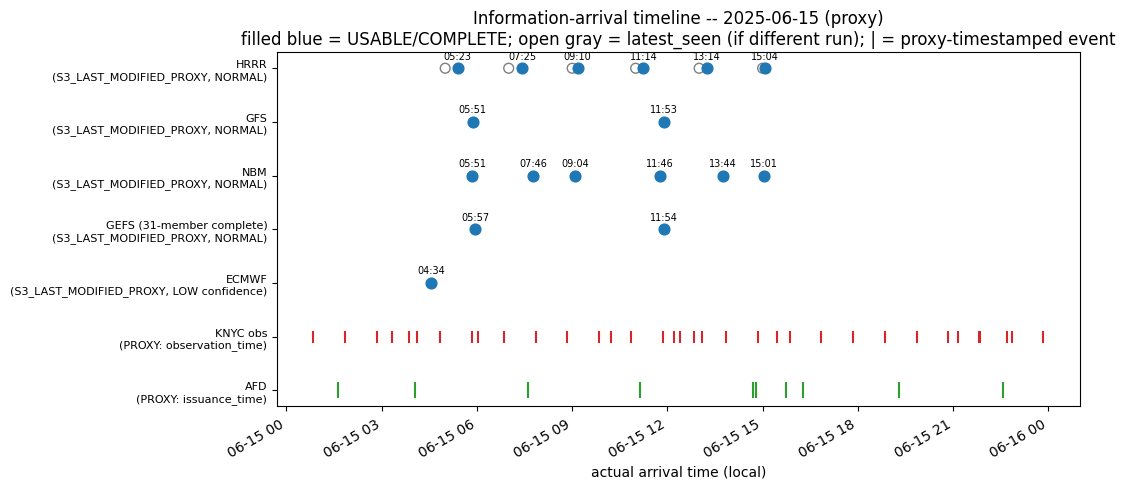

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
sources_meta = [
    ("hrrr_usable_since", "hrrr_latest_seen_run", "hrrr_run", "HRRR", "S3_LAST_MODIFIED_PROXY, NORMAL"),
    ("gfs_usable_since", "gfs_latest_seen_run", "gfs_run", "GFS", "S3_LAST_MODIFIED_PROXY, NORMAL"),
    ("nbm_usable_since", "nbm_latest_seen_run", "nbm_run", "NBM", "S3_LAST_MODIFIED_PROXY, NORMAL"),
    ("gefs_usable_since", None, "gefs_run", "GEFS (31-member complete)", "S3_LAST_MODIFIED_PROXY, NORMAL"),
    ("ecmwf_deterministic_usable_since", "ecmwf_deterministic_latest_seen_run", "ecmwf_deterministic_run", "ECMWF", "S3_LAST_MODIFIED_PROXY, LOW confidence"),
]
y_labels = []
for i, (usable_col, seen_col, run_col, label, avail_note) in enumerate(sources_meta):
    y = len(sources_meta) - i
    y_labels.append(f"{label}\n({avail_note})")
    seen_times = set()
    if seen_col and seen_col in day.columns:
        seen_rows = day.dropna(subset=[seen_col, run_col])
        seen_rows = seen_rows[seen_rows[seen_col] != seen_rows[run_col]]
        for _, r in seen_rows.iterrows():
            ax.scatter(pd.Timestamp(r[seen_col]).tz_convert("America/New_York"), y, marker="o", facecolors="none", edgecolors="gray", s=50, zorder=2)
            seen_times.add(r[seen_col])
    usable_rows = day.dropna(subset=[usable_col])
    plotted = set()
    for _, r in usable_rows.iterrows():
        ts = r[usable_col]
        if ts in plotted:
            continue
        plotted.add(ts)
        ax.scatter(pd.Timestamp(ts).tz_convert("America/New_York"), y, marker="o", color="tab:blue", s=60, zorder=3)
        ax.annotate(pd.Timestamp(ts).tz_convert("America/New_York").strftime("%H:%M"), (pd.Timestamp(ts).tz_convert("America/New_York"), y),
                    fontsize=7, xytext=(0, 7), textcoords="offset points", ha="center")

# Observations (PROXY availability -- real observation_time used directly as the proxy).
obs_all = pd.read_parquet(ROOT / "data/processed/pilot/observations/pilot_observations_canonical.parquet")
obs_all = obs_all[(obs_all["station_icao"] == "KNYC") & (obs_all["is_real_observation"] == True)]
day_start_utc = pd.Timestamp(TARGET_DATE, tz="America/New_York").tz_convert("UTC")
day_end_utc = day_start_utc + pd.Timedelta(days=1)
obs_today = obs_all[(obs_all["observation_time"] >= day_start_utc) & (obs_all["observation_time"] < day_end_utc)]
y_obs = 0
ax.scatter(obs_today["observation_time"].dt.tz_convert("America/New_York"), [y_obs] * len(obs_today), marker="|", color="tab:red", s=80, zorder=2)
y_labels_full = y_labels + ["KNYC obs\n(PROXY: observation_time)"]

# AFD (PROXY availability -- issuance_time used directly as the proxy).
afd_all = pd.read_parquet(ROOT / "data/processed/pilot/afd/pilot_afd_documents.parquet")
afd_all["issuance_time"] = pd.to_datetime(afd_all["issuance_time"], utc=True)
afd_today = afd_all[(afd_all["issuance_time"] >= day_start_utc) & (afd_all["issuance_time"] < day_end_utc)]
y_afd = -1
ax.scatter(afd_today["issuance_time"].dt.tz_convert("America/New_York"), [y_afd] * len(afd_today), marker="|", color="tab:green", s=120, zorder=2)
y_labels_full = y_labels_full + ["AFD\n(PROXY: issuance_time)"]

ax.set_yticks(list(range(len(sources_meta), -2, -1)))
ax.set_yticklabels(y_labels_full, fontsize=8)
ax.set_xlabel("actual arrival time (local)")
ax.set_title(f"Information-arrival timeline -- {TARGET_DATE} ({STATE_MODE})\nfilled blue = USABLE/COMPLETE; open gray = latest_seen (if different run); | = proxy-timestamped event")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Forecast Tmax evolution through the day

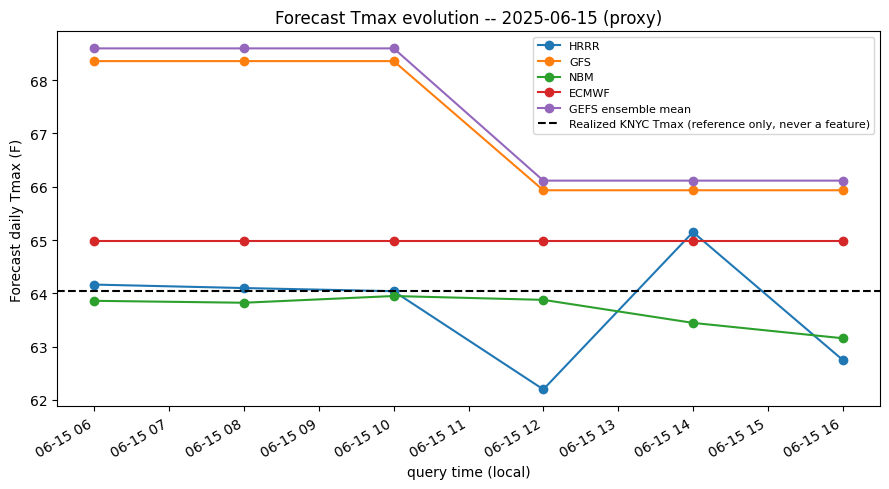

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for col, label in [("hrrr_forecast_tmax_f", "HRRR"), ("gfs_forecast_tmax_f", "GFS"), ("nbm_forecast_tmax_f", "NBM"),
                    ("ecmwf_deterministic_forecast_tmax_f", "ECMWF"), ("gefs_tmax_mean_f", "GEFS ensemble mean")]:
    ax.plot(day["query_time_local"], day[col], marker="o", label=label)
ax.axhline(day["label_tmax_f"].iloc[0], color="black", linestyle="--", label="Realized KNYC Tmax (reference only, never a feature)")
ax.set_ylabel("Forecast daily Tmax (F)")
ax.set_xlabel("query time (local)")
ax.set_title(f"Forecast Tmax evolution -- {TARGET_DATE} ({STATE_MODE})")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## GEFS ensemble uncertainty through the day

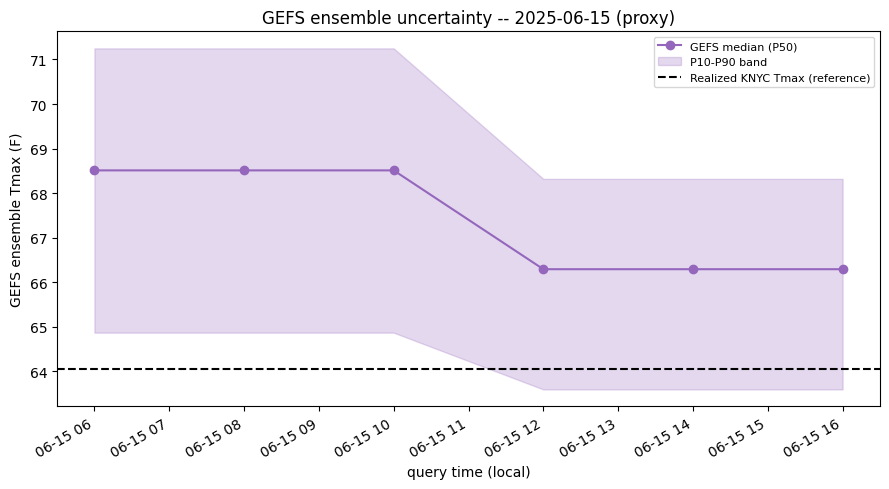

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(day["query_time_local"], day["gefs_tmax_p50_f"], marker="o", color="tab:purple", label="GEFS median (P50)")
ax.fill_between(day["query_time_local"], day["gefs_tmax_p10_f"], day["gefs_tmax_p90_f"], alpha=0.25, color="tab:purple", label="P10-P90 band")
ax.axhline(day["label_tmax_f"].iloc[0], color="black", linestyle="--", label="Realized KNYC Tmax (reference)")
ax.set_ylabel("GEFS ensemble Tmax (F)")
ax.set_xlabel("query time (local)")
ax.set_title(f"GEFS ensemble uncertainty -- {TARGET_DATE} ({STATE_MODE})")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## KNYC observation evolution through the day

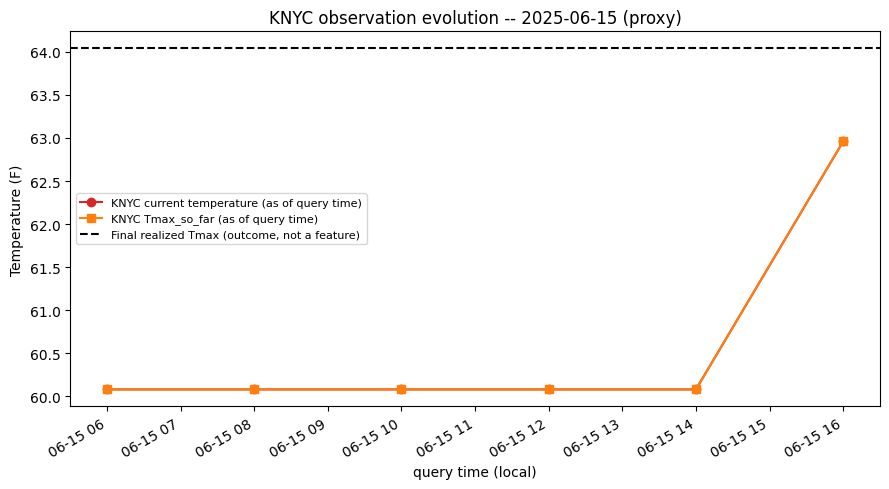

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(day["query_time_local"], day["KNYC_current_temp_f"], marker="o", color="tab:red", label="KNYC current temperature (as of query time)")
ax.plot(day["query_time_local"], day["KNYC_tmax_so_far_f"], marker="s", color="tab:orange", label="KNYC Tmax_so_far (as of query time)")
ax.axhline(day["label_tmax_f"].iloc[0], color="black", linestyle="--", label="Final realized Tmax (outcome, not a feature)")
ax.set_ylabel("Temperature (F)")
ax.set_xlabel("query time (local)")
ax.set_title(f"KNYC observation evolution -- {TARGET_DATE} ({STATE_MODE})")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Forecast trajectory view -- what did each model expect the WHOLE day to look like?

Pick one query time and see each source's target-day **instantaneous air temperature** trajectory (`valid_time` vs forecast temperature) -- the canonical instantaneous-temperature variable only (`TMP`/`2t`; for GEFS, the ensemble MEAN instantaneous temperature). Period max/min products (NBM's `TMAX_PERIOD`/`TMIN_PERIOD`, ECMWF's `mx2t3`/`mn2t3`/`mx2t6`/`mn2t6`) are deliberately EXCLUDED from this series -- connecting them together with instantaneous readings at the same `valid_time` previously produced misleading vertical lines (see `docs/integrated_pilot_validation.md`'s manual-inspection-follow-up addendum) and, more importantly, was silently inflating each source's reported daily-max forecast (`data/weather_state.py`'s `get_latest_forecast`/`get_ensemble_state` now isolate the instantaneous-temperature variable before any aggregation).

KNYC observations are overlaid for reference/analysis only: **solid** up to the query time (information that genuinely could have informed a forecast), **dashed/lighter** after it (future outcome data -- never available to the state at this query time, shown only for after-the-fact comparison).

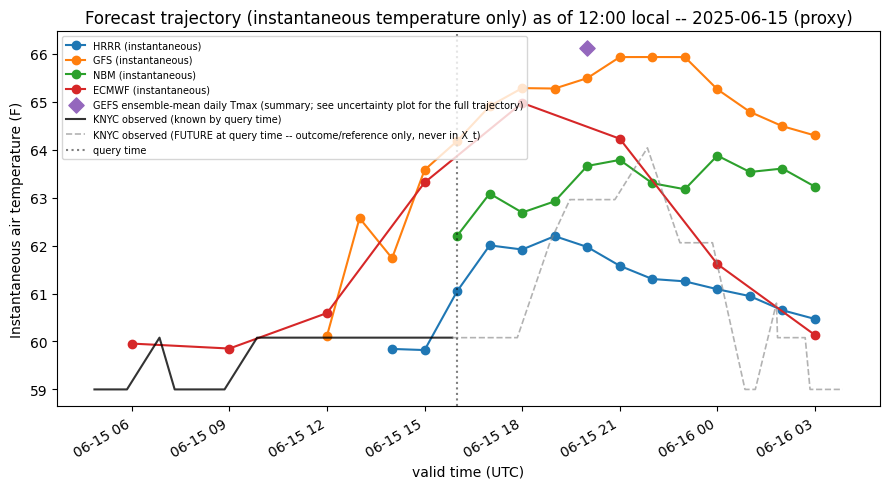

In [8]:
INSPECT_HOUR = 12  # change to any of 6, 8, 10, 12, 14, 16

sid_row = structured[(structured["target_date"] == TARGET_DATE) & (structured["local_hour"] == INSPECT_HOUR) & (structured["state_mode"] == STATE_MODE)]
sid = sid_row.iloc[0]["state_id"]
query_time_utc = sid_row.iloc[0]["query_time_utc"]
traj = trajectories[trajectories["state_id"] == sid]

fig, ax = plt.subplots(figsize=(9, 5))
for src, label in [("hrrr", "HRRR"), ("gfs", "GFS"), ("nbm", "NBM"), ("ecmwf_deterministic", "ECMWF")]:
    sub = traj[traj["source"] == src].sort_values("valid_time")
    if not sub.empty:
        ax.plot(pd.to_datetime(sub["valid_time"]), sub["temperature_f"], marker="o", label=f"{label} (instantaneous)")

# GEFS: ensemble MEAN instantaneous temperature trajectory (member-level detail
# lives in gefs_members.parquet / the GEFS uncertainty plot above, not mixed
# into this single-line view).
gefs_run = sid_row.iloc[0]["gefs_run"]
if pd.notna(gefs_run):
    # Per-valid_time ensemble-mean trajectory is not precomputed in structured
    # features; this view shows only the 4 deterministic sources' full
    # instantaneous-temperature series plus GEFS's single daily-max summary
    # point (see the dedicated GEFS uncertainty plot above for its full
    # ensemble picture through the day).
    ax.scatter([pd.Timestamp(TARGET_DATE, tz="America/New_York").tz_convert("UTC") + pd.Timedelta(hours=16)],
               [sid_row.iloc[0]["gefs_tmax_mean_f"]], marker="D", color="tab:purple", s=60, label="GEFS ensemble-mean daily Tmax (summary; see uncertainty plot for the full trajectory)")

obs_day = pd.read_parquet(ROOT / "data/processed/pilot/observations/pilot_observations_canonical.parquet")
obs_day = obs_day[(obs_day["station_icao"] == "KNYC") & (obs_day["is_real_observation"] == True)]
day_start, day_end = pd.Timestamp(TARGET_DATE, tz="America/New_York").tz_convert("UTC"), pd.Timestamp(TARGET_DATE, tz="America/New_York").tz_convert("UTC") + pd.Timedelta(days=1)
obs_day = obs_day[(obs_day["observation_time"] >= day_start) & (obs_day["observation_time"] < day_end)].sort_values("observation_time")

obs_past = obs_day[obs_day["observation_time"] <= query_time_utc]
obs_future = obs_day[obs_day["observation_time"] > query_time_utc]
ax.plot(obs_past["observation_time"], obs_past["temperature_f"], color="black", linewidth=1.5, alpha=0.8, label="KNYC observed (known by query time)")
if not obs_future.empty:
    # Bridge the gap so the dashed segment visually connects to the known segment.
    bridge = pd.concat([obs_past.tail(1), obs_future])
    ax.plot(bridge["observation_time"], bridge["temperature_f"], color="gray", linewidth=1.2, linestyle="--", alpha=0.6,
            label="KNYC observed (FUTURE at query time -- outcome/reference only, never in X_t)")
ax.axvline(query_time_utc, color="black", linestyle=":", alpha=0.5, label="query time")

ax.set_ylabel("Instantaneous air temperature (F)")
ax.set_xlabel("valid time (UTC)")
ax.set_title(f"Forecast trajectory (instantaneous temperature only) as of {INSPECT_HOUR}:00 local -- {TARGET_DATE} ({STATE_MODE})")
ax.legend(fontsize=7, loc="best")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Missingness matrix -- 40 days x 6 standard query times

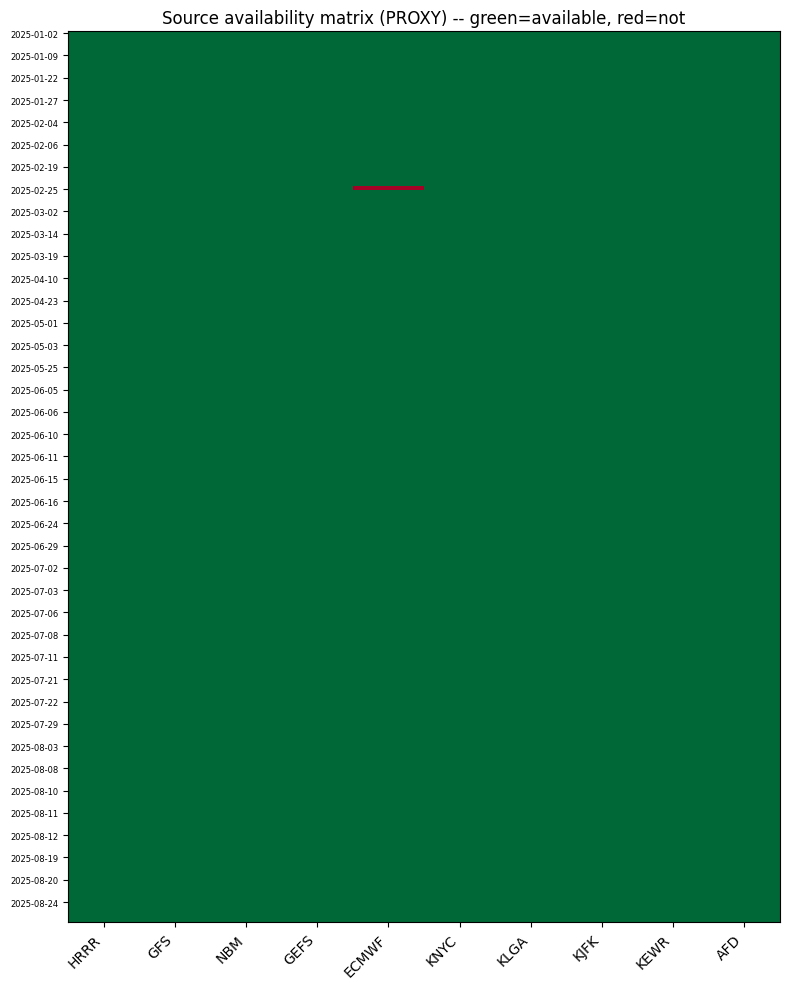

In [9]:
pivot_data = {}
for src, col in [("HRRR", "hrrr_usable_for_daily_max"), ("GFS", "gfs_usable_for_daily_max"), ("NBM", "nbm_usable_for_daily_max"),
                  ("GEFS", "gefs_usable_for_daily_max"), ("ECMWF", "ecmwf_deterministic_usable_for_daily_max"),
                  ("KNYC", "KNYC_available"), ("KLGA", "KLGA_available"), ("KJFK", "KJFK_available"), ("KEWR", "KEWR_available"),
                  ("AFD", "afd_available")]:
    sub = structured[structured["state_mode"] == STATE_MODE]
    pivot_data[src] = sub.groupby(["target_date", "local_hour"])[col].first()

matrix = pd.DataFrame(pivot_data).astype(float)
fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(matrix.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(0, len(matrix), 6))
ax.set_yticklabels([matrix.index[i][0] for i in range(0, len(matrix), 6)], fontsize=6)
ax.set_title(f"Source availability matrix ({STATE_MODE.upper()}) -- green=available, red=not")
plt.tight_layout()
plt.show()

## Source freshness (age at query time)

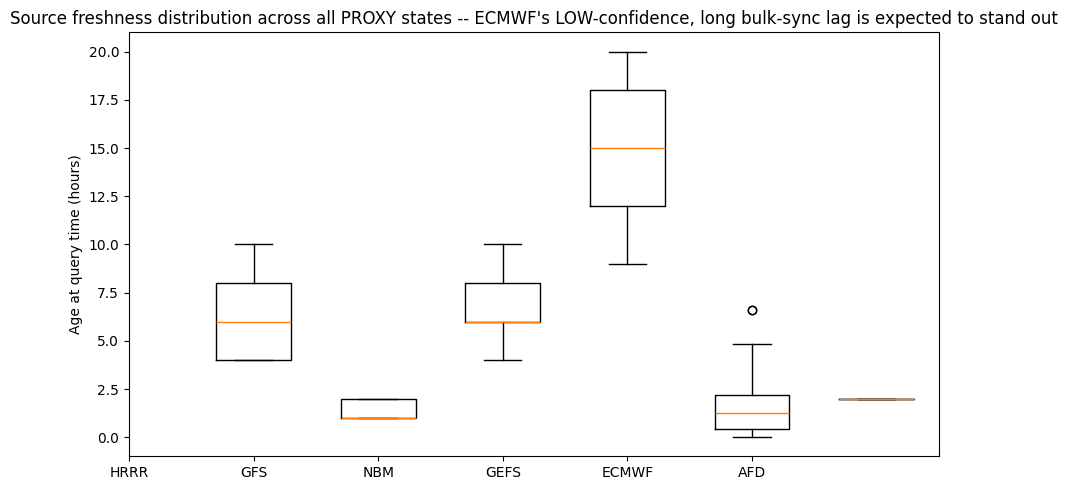

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sub = structured[structured["state_mode"] == STATE_MODE]
for col, label in [("hrrr_age_hours", "HRRR"), ("gfs_age_hours", "GFS"), ("nbm_age_hours", "NBM"),
                    ("gefs_age_hours", "GEFS"), ("ecmwf_deterministic_age_hours", "ECMWF"), ("afd_age_hours", "AFD")]:
    ax.boxplot(sub[col].dropna(), positions=[len(ax.get_xticklabels())], widths=0.6)
ax.set_xticks(range(6))
ax.set_xticklabels(["HRRR", "GFS", "NBM", "GEFS", "ECMWF", "AFD"])
ax.set_ylabel("Age at query time (hours)")
ax.set_title(f"Source freshness distribution across all {STATE_MODE.upper()} states -- ECMWF's LOW-confidence, long bulk-sync lag is expected to stand out")
plt.tight_layout()
plt.show()

## STRICT vs PROXY comparison

In [11]:
strict_row = structured[(structured["target_date"] == TARGET_DATE) & (structured["local_hour"] == 12) & (structured["state_mode"] == "strict")].iloc[0]
proxy_row = structured[(structured["target_date"] == TARGET_DATE) & (structured["local_hour"] == 12) & (structured["state_mode"] == "proxy")].iloc[0]

compare_cols = ["hrrr_forecast_tmax_f", "gfs_forecast_tmax_f", "nbm_forecast_tmax_f", "gefs_tmax_mean_f", "ecmwf_deterministic_forecast_tmax_f",
                "KNYC_available", "KNYC_current_temp_f", "KNYC_tmax_so_far_f", "afd_available", "afd_age_hours"]
comparison = pd.DataFrame({"STRICT": strict_row[compare_cols], "PROXY": proxy_row[compare_cols]})
print(f"Comparison at {TARGET_DATE} 12:00 local:")
comparison

Comparison at 2025-06-15 12:00 local:


,STRICT,PROXY
hrrr_forecast_tmax_f,62.19778,62.19778
gfs_forecast_tmax_f,65.934219,65.934219
nbm_forecast_tmax_f,63.877974,63.877974
gefs_tmax_mean_f,66.114694,66.114694
ecmwf_deterministic_forecast_tmax_f,64.977073,64.977073
KNYC_available,False,True
KNYC_current_temp_f,NaN,60.08
KNYC_tmax_so_far_f,NaN,60.08
afd_available,False,True
afd_age_hours,NaN,0.866667


---
## Summary

This notebook is read-only inspection tooling. To rebuild the underlying dataset after any code change, run:

```
python scripts/build_integrated_pilot.py
python scripts/audit_integrated_pilot.py
```

See `docs/integrated_pilot_validation.md` for the full validation report and `docs/how_to_inspect_integrated_dataset.md` for a beginner-friendly guide to every column and plot.